# **Many Artificial LSST Lightcurves based on Observations of Real Nuclear Transients (MALLORN) - Using the Data Demonstration Notebook**

This notebook outlines the process of loading in the data for the lightcurve of a chosen object, including the relevant information about the object from the log file. It also provides a demonstration of how to split the data according to the band (u, g, r, i, z, y) and how to perform the necessary de-extinction to the lightcurve.

## **Step One** : Loading in the lightcurve data

In [62]:
# Local data paths (no Google Drive)
from pathlib import Path

DATA_ROOT = Path('datasets')
LOAD_ALL_SPLITS = True
SPLIT = 'split_01'

if LOAD_ALL_SPLITS:
    split_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and p.name.startswith('split_')])
    LIGHTCURVE_PATHS = [p / 'train_full_lightcurves.csv' for p in split_dirs if (p / 'train_full_lightcurves.csv').exists()]
else:
    LIGHTCURVE_PATHS = [DATA_ROOT / SPLIT / 'train_full_lightcurves.csv']

LOG_PATH = DATA_ROOT / 'train_log.csv'

print('Lightcurves:', LIGHTCURVE_PATHS)
print('Log:', LOG_PATH)


Lightcurves: [PosixPath('datasets/split_01/train_full_lightcurves.csv'), PosixPath('datasets/split_02/train_full_lightcurves.csv'), PosixPath('datasets/split_03/train_full_lightcurves.csv'), PosixPath('datasets/split_04/train_full_lightcurves.csv'), PosixPath('datasets/split_05/train_full_lightcurves.csv'), PosixPath('datasets/split_06/train_full_lightcurves.csv'), PosixPath('datasets/split_07/train_full_lightcurves.csv'), PosixPath('datasets/split_08/train_full_lightcurves.csv'), PosixPath('datasets/split_09/train_full_lightcurves.csv'), PosixPath('datasets/split_10/train_full_lightcurves.csv'), PosixPath('datasets/split_11/train_full_lightcurves.csv'), PosixPath('datasets/split_12/train_full_lightcurves.csv'), PosixPath('datasets/split_13/train_full_lightcurves.csv'), PosixPath('datasets/split_14/train_full_lightcurves.csv'), PosixPath('datasets/split_15/train_full_lightcurves.csv'), PosixPath('datasets/split_16/train_full_lightcurves.csv'), PosixPath('datasets/split_17/train_full_li

### **1.1 : Importing the necessary packages**



In [63]:
#Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Setting filter colours for later plotting
filter_colours = {'u': '#6A5ACD', 'g': '#2ca02c', 'r': '#d62728', 'i': '#ff7f0e', 'z': '#8c564b', 'y': '#1b1b1b'}

### **1.2: Loading in the lightcurve data**

In [64]:
# Reading lightcurve data into a dataframe
dfs = [pd.read_csv(p) for p in LIGHTCURVE_PATHS]
df = pd.concat(dfs, ignore_index=True)
print(df.head())


                  object_id  Time (MJD)       Flux  Flux_err Filter
0  Dornhoth_fervain_onodrim  63314.4662  -1.630159  0.365777      z
1  Dornhoth_fervain_onodrim  63780.9674  10.499389  0.253867      r
2  Dornhoth_fervain_onodrim  63789.7693   5.866250  1.559241      y
3  Dornhoth_fervain_onodrim  63794.1702   3.903623  0.376854      r
4  Dornhoth_fervain_onodrim  63794.1702   5.226644  0.516864      i


### **1.3: Isolating data for chosen object and splitting according to filter**

In [65]:
# Define name of chosen object
object_ID = 'amon_imloth_luin'

if object_ID not in df['object_id'].values:
    object_ID = df['object_id'].iloc[0]
    print('Object not found, using first object:', object_ID)

# Creating masks to isolate data for chosen lightcurve and split according to filter
u_mask = ((df['Filter'] == 'u') & (df['object_id'] == object_ID))
g_mask = ((df['Filter'] == 'g') & (df['object_id'] == object_ID))
r_mask = ((df['Filter'] == 'r') & (df['object_id'] == object_ID))
i_mask = ((df['Filter'] == 'i') & (df['object_id'] == object_ID))
z_mask = ((df['Filter'] == 'z') & (df['object_id'] == object_ID))
y_mask = ((df['Filter'] == 'y') & (df['object_id'] == object_ID))


In [66]:
# Extract per-band arrays
def band_arrays(mask):
    sub = df.loc[mask, ['Time (MJD)', 'Flux', 'Flux_err']].sort_values('Time (MJD)')
    return (
        sub['Time (MJD)'].to_numpy(),
        sub['Flux'].to_numpy(),
        sub['Flux_err'].to_numpy(),
    )

u_time, u_flux, u_err = band_arrays(u_mask)
g_time, g_flux, g_err = band_arrays(g_mask)
r_time, r_flux, r_err = band_arrays(r_mask)
i_time, i_flux, i_err = band_arrays(i_mask)
z_time, z_flux, z_err = band_arrays(z_mask)
y_time, y_flux, y_err = band_arrays(y_mask)


### **1.4: Loading in log data**

In [67]:
# Loading in log data file
log_path = LOG_PATH
log_df = pd.read_csv(log_path)

# Selecting only the data relevant to the chosen object
object_log = log_df.loc[log_df['object_id'] == object_ID]
print(object_log)

# Defining the redshift of that object
redshift = float(object_log['Z'].iloc[0])

# redshift_err = object_log['Z_err']
# For training set, it is a spectroscopically determined redshift (with negligible error).
# For testing set, it will be a photometrically determined redshift and will have an error value.

ebv = float(object_log['EBV'].iloc[0])
# Loading in the extinction coefficient value
# Dust in the Milky Way can obscure the light from a distant object.

SpecType = object_log['SpecType'].iloc[0]
# For the training set, the type of the object will be listed in the 'SpecType' column
# For the testing set, this value will not be present


           object_id       Z  Z_err    EBV SpecType  \
12  amon_imloth_luin  0.7766    NaN  0.055      TDE   

                                  English Translation     split  target  
12  hill, steep-sided mount  +  flowering valley  ...  split_01       1  


## **Step Two** : De-extincting and plotting the lightcurve data

### **2.1: Loading necessary package and defining de-extinction function**

In [68]:
#Importing necessary package
from extinction import fitzpatrick99

#Defining function to de-extinct a set of flux values
def jurassic_park (flux, eff_wl):
    A_lambda = fitzpatrick99(eff_wl, ebv * 3.1) #3.1 = Standard Milky Way value
    flux_ext = flux * 10**((A_lambda)/2.5)
    return flux_ext, A_lambda

### **2.2: De-extincting fluxes**

In [69]:
#Effective wavelength for each band - sourced from SVO Filter Profile Service
u_eff_wl = np.array([3641]); g_eff_wl = np.array([4704]); r_eff_wl = np.array([6155])
i_eff_wl = np.array([7504]); z_eff_wl = np.array([8695]); y_eff_wl = np.array([10056])

#De-extincting lightcurves
u_flux, u_A_lambda = jurassic_park(u_flux,u_eff_wl); g_flux, g_A_lambda = jurassic_park(g_flux,g_eff_wl)
r_flux, r_A_lambda = jurassic_park(r_flux,r_eff_wl); i_flux, i_A_lambda = jurassic_park(i_flux,i_eff_wl)
z_flux, z_A_lumbda = jurassic_park(z_flux,z_eff_wl) ;y_flux, y_A_lambda = jurassic_park(y_flux,y_eff_wl)

print(f'u band extinction = {u_A_lambda}'); print(f'g band extinction = {g_A_lambda}'); print(f'r band extinction = {r_A_lambda}')
print(f'i band extinction = {i_A_lambda}'); print(f'z band extinction = {z_A_lumbda}'); print(f'y band extinction = {y_A_lambda}')

u band extinction = [0.26116086]
g band extinction = [0.20746283]
r band extinction = [0.14256113]
i band extinction = [0.1049135]
z band extinction = [0.08188936]
y band extinction = [0.06363456]


### **2.3: Plotting lightcurve**

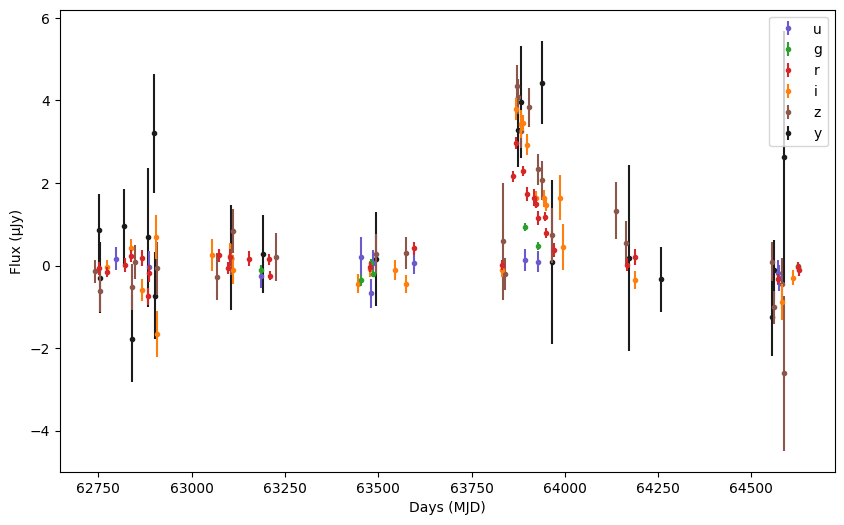

In [70]:
plt.figure(figsize = [10,6])
plt.errorbar(u_time,u_flux, yerr= u_err,label='u', fmt = '.',color = filter_colours['u'],zorder=4)
plt.errorbar(g_time,g_flux,yerr=g_err, label='g', fmt = '.', color = filter_colours['g'],zorder=5)
plt.errorbar(r_time,r_flux,yerr = r_err, label='r', fmt = '.', color = filter_colours['r'],zorder=6)
plt.errorbar(i_time,i_flux,yerr = i_err, label='i', fmt = '.', color = filter_colours['i'],zorder=3)
plt.errorbar(z_time,z_flux,yerr = z_err, label='z', fmt = '.', color = filter_colours['z'],zorder=2)
plt.errorbar(y_time,y_flux,yerr = y_err, label='y', fmt = '.', color = filter_colours['y'],zorder=1)
plt.xlabel('Days (MJD)')
plt.ylabel('Flux (μJy)')
plt.legend()
plt.show()

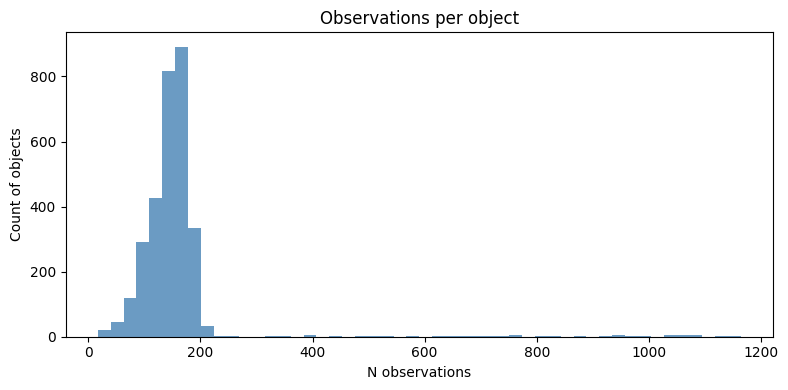

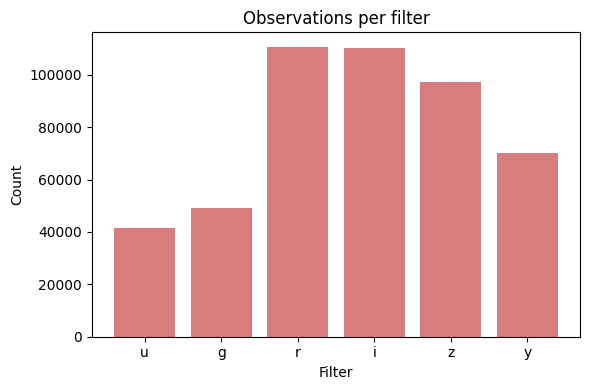

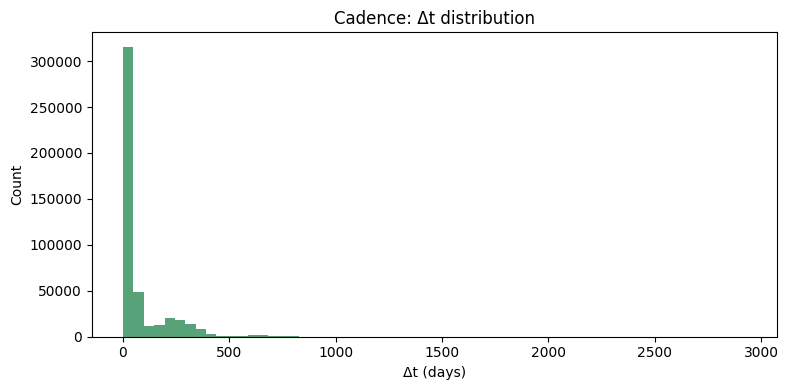

/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_43358/3738171810.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['u','g','r','i','z','y'], showfliers=False)


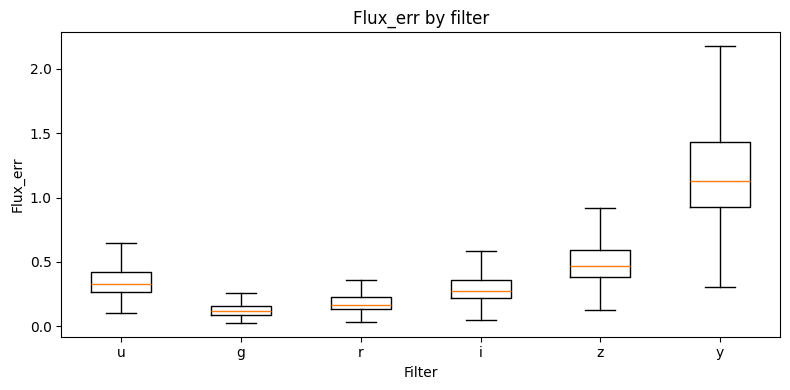

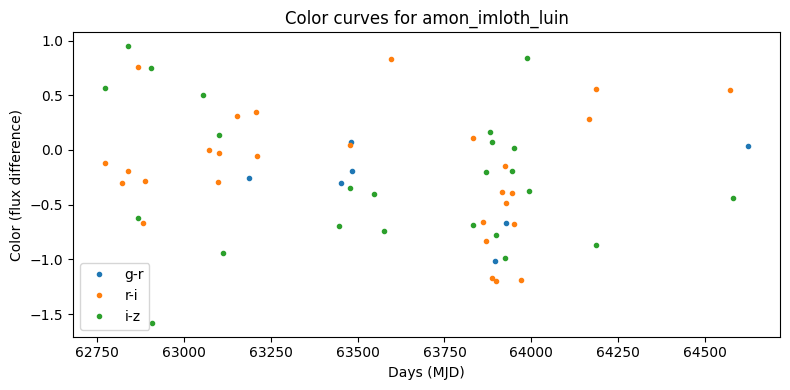

Quick features (all filters):
{'t_peak': 63938.3754, 'time_to_peak': 1197.8843999999954, 'peak_flux': 4.17405661, 'fwhm': 1688.2607000000062, 'wmean_flux': 0.4191970516163965, 'von_neumann': 0.8578153914147658}


In [71]:
# Step Three: EDA plots and quick feature prototype
# Uses df (lightcurves), log_df (train_log), and object_ID from earlier cells.

# 1) Observations per object
obj_counts = df.groupby('object_id').size()
plt.figure(figsize=(8, 4))
plt.hist(obj_counts, bins=50, color='steelblue', alpha=0.8)
plt.title('Observations per object')
plt.xlabel('N observations')
plt.ylabel('Count of objects')
plt.tight_layout()
plt.show()

# 2) Observations per filter
filter_counts = df.groupby('Filter').size().reindex(['u','g','r','i','z','y'])
plt.figure(figsize=(6, 4))
plt.bar(filter_counts.index, filter_counts.values, color='indianred', alpha=0.8)
plt.title('Observations per filter')
plt.xlabel('Filter')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3) Cadence distribution (delta t)
df_sorted = df.sort_values('Time (MJD)')
dt = df_sorted.groupby(['object_id', 'Filter'])['Time (MJD)'].diff()
dt = dt.dropna()
plt.figure(figsize=(8, 4))
plt.hist(dt, bins=60, color='seagreen', alpha=0.8)
plt.title('Cadence: Δt distribution')
plt.xlabel('Δt (days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4) Flux error distribution per filter
plt.figure(figsize=(8, 4))
data = [df.loc[df['Filter'] == f, 'Flux_err'].dropna() for f in ['u','g','r','i','z','y']]
plt.boxplot(data, labels=['u','g','r','i','z','y'], showfliers=False)
plt.title('Flux_err by filter')
plt.xlabel('Filter')
plt.ylabel('Flux_err')
plt.tight_layout()
plt.show()

# 5) Color curves for selected object (g-r, r-i, i-z)
def _color_curve(time_a, flux_a, time_b, flux_b):
    if len(time_a) < 2 or len(time_b) < 2:
        return None, None
    idx_a = np.argsort(time_a)
    idx_b = np.argsort(time_b)
    time_a = time_a[idx_a]
    flux_a = flux_a[idx_a]
    time_b = time_b[idx_b]
    flux_b = flux_b[idx_b]
    lo, hi = time_b.min(), time_b.max()
    mask = (time_a >= lo) & (time_a <= hi)
    if np.sum(mask) < 2:
        return None, None
    time_use = time_a[mask]
    flux_b_interp = np.interp(time_use, time_b, flux_b)
    return time_use, flux_a[mask] - flux_b_interp

plt.figure(figsize=(8, 4))
t_gr, c_gr = _color_curve(g_time, g_flux, r_time, r_flux)
t_ri, c_ri = _color_curve(r_time, r_flux, i_time, i_flux)
t_iz, c_iz = _color_curve(i_time, i_flux, z_time, z_flux)
if t_gr is not None:
    plt.plot(t_gr, c_gr, '.', label='g-r')
if t_ri is not None:
    plt.plot(t_ri, c_ri, '.', label='r-i')
if t_iz is not None:
    plt.plot(t_iz, c_iz, '.', label='i-z')
plt.title(f'Color curves for {object_ID}')
plt.xlabel('Days (MJD)')
plt.ylabel('Color (flux difference)')
plt.legend()
plt.tight_layout()
plt.show()

# 6) Quick feature prototype for the selected object
def _quick_features(time, flux, err):
    if len(time) == 0:
        return {}
    idx = np.argsort(time)
    time = time[idx]
    flux = flux[idx]
    err = err[idx]
    peak_idx = int(np.nanargmax(flux))
    t_peak = time[peak_idx]
    peak_flux = flux[peak_idx]
    half = 0.5 * peak_flux
    above = flux >= half
    fwhm = (time[above][-1] - time[above][0]) if np.any(above) and np.sum(above) > 1 else np.nan
    # weighted mean
    mask = np.isfinite(err) & (err > 0)
    if np.any(mask):
        w = 1.0 / (err[mask] ** 2 + 1e-6)
        wmean = np.sum(w * flux[mask]) / np.sum(w)
    else:
        wmean = np.nan
    # von Neumann ratio
    var = np.var(flux, ddof=0)
    vn = (np.sum(np.diff(flux) ** 2) / (len(flux) - 1)) / var if len(flux) > 1 and var > 0 else np.nan
    return {
        't_peak': float(t_peak),
        'time_to_peak': float(t_peak - time[0]),
        'peak_flux': float(peak_flux),
        'fwhm': float(fwhm) if np.isfinite(fwhm) else np.nan,
        'wmean_flux': float(wmean) if np.isfinite(wmean) else np.nan,
        'von_neumann': float(vn) if np.isfinite(vn) else np.nan,
    }

obj_mask = df['object_id'] == object_ID
obj_df = df.loc[obj_mask]
obj_time = obj_df['Time (MJD)'].to_numpy()
obj_flux = obj_df['Flux'].to_numpy()
obj_err = obj_df['Flux_err'].to_numpy()
features_preview = _quick_features(obj_time, obj_flux, obj_err)
print('Quick features (all filters):')
print(features_preview)


   n_obs  peak_flux       fwhm  wmean_flux  von_neumann  target
0  162.0   3.690515  1560.1025    0.351494     0.851237       1
1  174.0   4.166283   272.8878    0.280838     1.104284       1
2  141.0   5.542737  1556.4703    0.413919     0.680240       1
3  151.0   3.003236  1854.4414    0.233834     0.851131       1
4  181.0   5.018182    91.1373    0.292893     0.656523       1


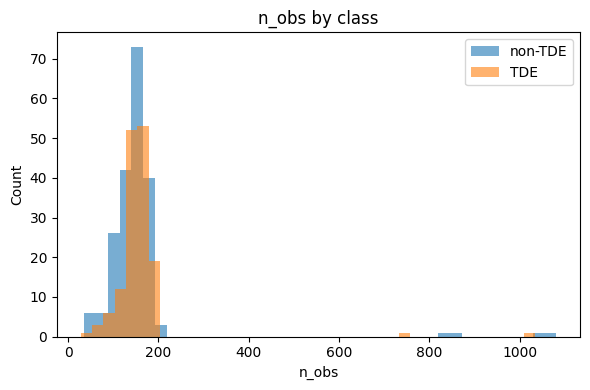

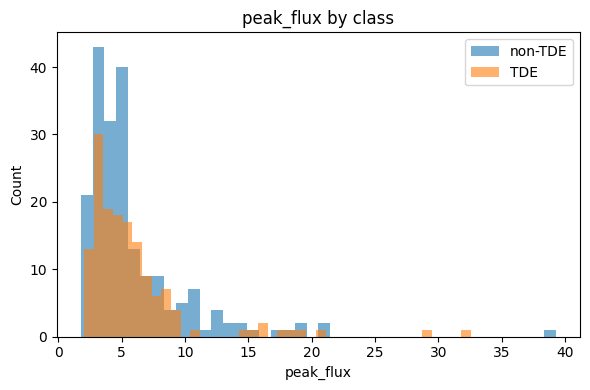

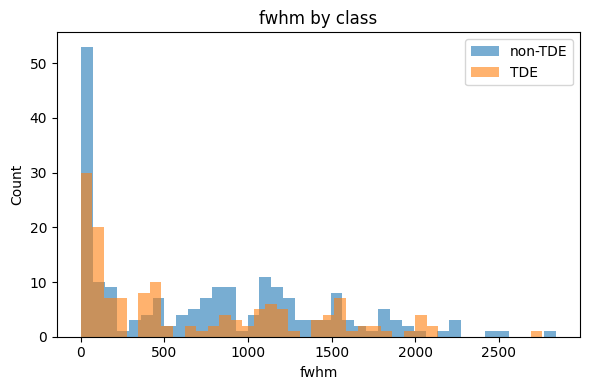

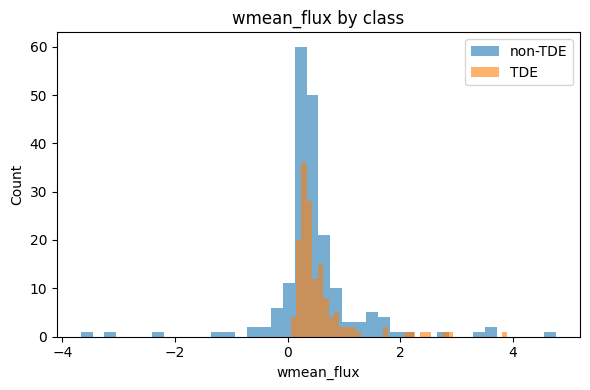

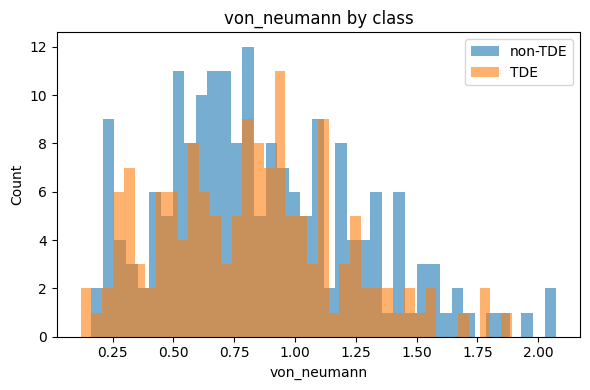

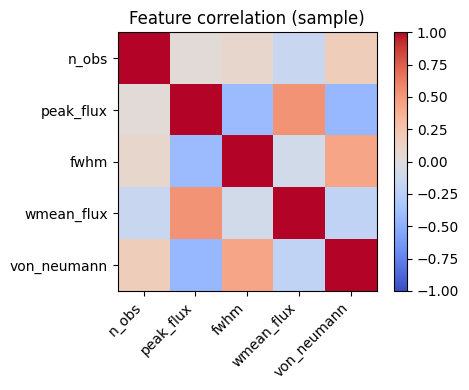

In [72]:
# Step Four: class comparison + correlation checks
# Requires: df, log_df, object_ID, and band_arrays from earlier cells.

# 1) Sample a subset of objects per class to keep it fast
def sample_objects_by_class(log_df, n_per_class=200, seed=42):
    rng = np.random.default_rng(seed)
    pos = log_df.loc[log_df['target'] == 1, 'object_id'].unique()
    neg = log_df.loc[log_df['target'] == 0, 'object_id'].unique()
    n_pos = min(len(pos), n_per_class)
    n_neg = min(len(neg), n_per_class)
    pos_sel = rng.choice(pos, size=n_pos, replace=False)
    neg_sel = rng.choice(neg, size=n_neg, replace=False)
    return pos_sel, neg_sel

def quick_obj_features(obj_df):
    time = obj_df['Time (MJD)'].to_numpy()
    flux = obj_df['Flux'].to_numpy()
    err = obj_df['Flux_err'].to_numpy()
    if len(time) == 0:
        return None
    idx = np.argsort(time)
    time = time[idx]
    flux = flux[idx]
    err = err[idx]
    peak_idx = int(np.nanargmax(flux))
    t_peak = time[peak_idx]
    peak_flux = flux[peak_idx]
    half = 0.5 * peak_flux
    above = flux >= half
    fwhm = (time[above][-1] - time[above][0]) if np.any(above) and np.sum(above) > 1 else np.nan
    # weighted mean
    mask = np.isfinite(err) & (err > 0)
    if np.any(mask):
        w = 1.0 / (err[mask] ** 2 + 1e-6)
        wmean = np.sum(w * flux[mask]) / np.sum(w)
    else:
        wmean = np.nan
    # von Neumann ratio
    var = np.var(flux, ddof=0)
    vn = (np.sum(np.diff(flux) ** 2) / (len(flux) - 1)) / var if len(flux) > 1 and var > 0 else np.nan
    return {
        'n_obs': float(len(time)),
        'peak_flux': float(peak_flux),
        'fwhm': float(fwhm) if np.isfinite(fwhm) else np.nan,
        'wmean_flux': float(wmean) if np.isfinite(wmean) else np.nan,
        'von_neumann': float(vn) if np.isfinite(vn) else np.nan,
    }

pos_ids, neg_ids = sample_objects_by_class(log_df, n_per_class=200)

rows = []
for oid in pos_ids:
    obj_df = df.loc[df['object_id'] == oid]
    feats = quick_obj_features(obj_df)
    if feats is not None:
        feats['target'] = 1
        rows.append(feats)
for oid in neg_ids:
    obj_df = df.loc[df['object_id'] == oid]
    feats = quick_obj_features(obj_df)
    if feats is not None:
        feats['target'] = 0
        rows.append(feats)

feat_df = pd.DataFrame(rows)
print(feat_df.head())

# 2) Compare distributions by class
for col in ['n_obs', 'peak_flux', 'fwhm', 'wmean_flux', 'von_neumann']:
    plt.figure(figsize=(6, 4))
    plt.hist(feat_df.loc[feat_df['target']==0, col].dropna(), bins=40, alpha=0.6, label='non-TDE')
    plt.hist(feat_df.loc[feat_df['target']==1, col].dropna(), bins=40, alpha=0.6, label='TDE')
    plt.title(f'{col} by class')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) Correlation heatmap
corr = feat_df.drop(columns=['target']).corr()
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature correlation (sample)')
plt.tight_layout()
plt.show()


In [73]:
# Step Five: compact feature set (for training pipeline)
feature_df = globals().get("feature_df")
# This builds a recommended whitelist based on the feature names used in pipeline.ipynb.

FILTERS = ['u','g','r','i','z','y']

# Core per-object features
core = [
    't_peak_all', 'decay_time_all', 'peak_flux', 'peak_snr',
    'shape_all_time_to_peak', 'shape_all_fwhm', 'shape_all_rise_time_50',
    'shape_all_fall_time_50', 'shape_all_asym_50',
    'decay_slope', 'decay_r2',
    'var_all_stetson_j', 'var_all_stetson_k', 'var_all_vonneumann',
    'flux_all_mad', 'flux_all_iqr',
    'flux_all_wmean', 'flux_all_wstd',
    'cadence_span', 'cadence_gap_median', 'cadence_gap_p90',
]

# Per-filter features
per_filter = []
for f in FILTERS:
    per_filter += [
        f'flux_{f}_mean', f'flux_{f}_std', f'flux_{f}_mad', f'flux_{f}_iqr',
        f'flux_{f}_wmean', f'flux_{f}_wstd',
        f'shape_{f}_time_to_peak', f'shape_{f}_fwhm',
        f'shape_{f}_rise_time_50', f'shape_{f}_fall_time_50', f'shape_{f}_asym_50',
        f'var_{f}_stetson_j', f'var_{f}_stetson_k', f'var_{f}_vonneumann',
    ]

# Color features
colors = []
for a, b in [('g','r'),('r','i'),('i','z'),('u','g'),('z','y')]:
    colors.append(f'color_{a}_{b}')
    colors.append(f'color_{a}_{b}_slope')

FEATURE_WHITELIST = core + per_filter + colors
print('Feature whitelist size:', len(FEATURE_WHITELIST))

# If you already computed a feature matrix as feature_df, you can filter it: 
if feature_df is not None:
    keep = [c for c in FEATURE_WHITELIST if c in feature_df.columns]
    print('Matched features:', len(keep))
    feature_df_compact = feature_df[keep].copy()
    display(feature_df_compact.head())


Feature whitelist size: 115
Matched features: 113


,t_peak_all,decay_time_all,peak_flux,peak_snr,shape_all_time_to_peak,shape_all_fwhm,shape_all_rise_time_50,shape_all_fall_time_50,shape_all_asym_50,var_all_stetson_j,...,color_g_r,color_g_r_slope,color_r_i,color_r_i_slope,color_i_z,color_i_z_slope,color_u_g,color_u_g_slope,color_z_y,color_z_y_slope
0,1782.9972,1234.1329,4.430766,18.005662,1782.9972,1224.3897,0.0,0.0,NaN,2.057394,...,0.112896,0.000080,0.035010,0.000253,0.305864,-0.000021,0.923755,-0.000210,0.025842,-0.000183
1,928.7771,780.8826,2.087498,2.165708,928.7771,1557.8214,0.0,0.0,NaN,0.003837,...,-0.410885,NaN,-0.231051,NaN,-0.045714,NaN,0.042325,NaN,0.313453,NaN
2,365.8187,1899.2506,8.144880,69.175031,365.8187,1866.6777,0.0,0.0,NaN,2.219883,...,-0.062792,0.000923,-0.192777,0.000143,-0.141687,0.000485,-0.267941,0.002319,0.747788,0.001210
3,455.9586,1264.4626,12.945873,59.879078,455.9586,30.5539,0.0,0.0,NaN,2.853247,...,-0.566694,0.000400,-0.340043,0.001408,0.316095,-0.000007,-0.080862,0.000374,0.218491,-0.001180
4,457.6993,796.5726,25.047343,62.338923,457.6993,0.0000,0.0,0.0,NaN,7.303544,...,-1.448894,0.000116,-1.037012,-0.002294,0.842134,-0.002246,0.958393,0.001871,1.671238,0.001622
